<a href="https://colab.research.google.com/github/Ehsan-Roohi/DSMC_Python/blob/main/Bijan_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Please choose the collision method:
  [1] Simplified Bernoulli Trials (SBT)
  [2] Deterministic Closest-Pair (DCP)
Enter choice (1 or 2): 2
--- DSMC Relaxation to Maxwell-Boltzmann ---
--- Using Collision Method: DCP ---
--- Particles per Cell: 5 ---
Initializing particles with a UNIFORM random velocity distribution...
Velocities scaled to match initial temperature T_INIT = 273.0K.

Starting main simulation loop...
Step: 1000/10000...
Step: 2000/10000...
Step: 3000/10000...
Step: 4000/10000...
Step: 5000/10000...
Step: 6000/10000...
Step: 7000/10000...
Step: 8000/10000...
Step: 9000/10000...
Step: 10000/10000...
Simulation finished in 109.36 seconds.

Collision probability check passed (max prob = 0.000).
Final Equilibrium Temperature: 273.00 K
Plotting final speed distribution for DCP...


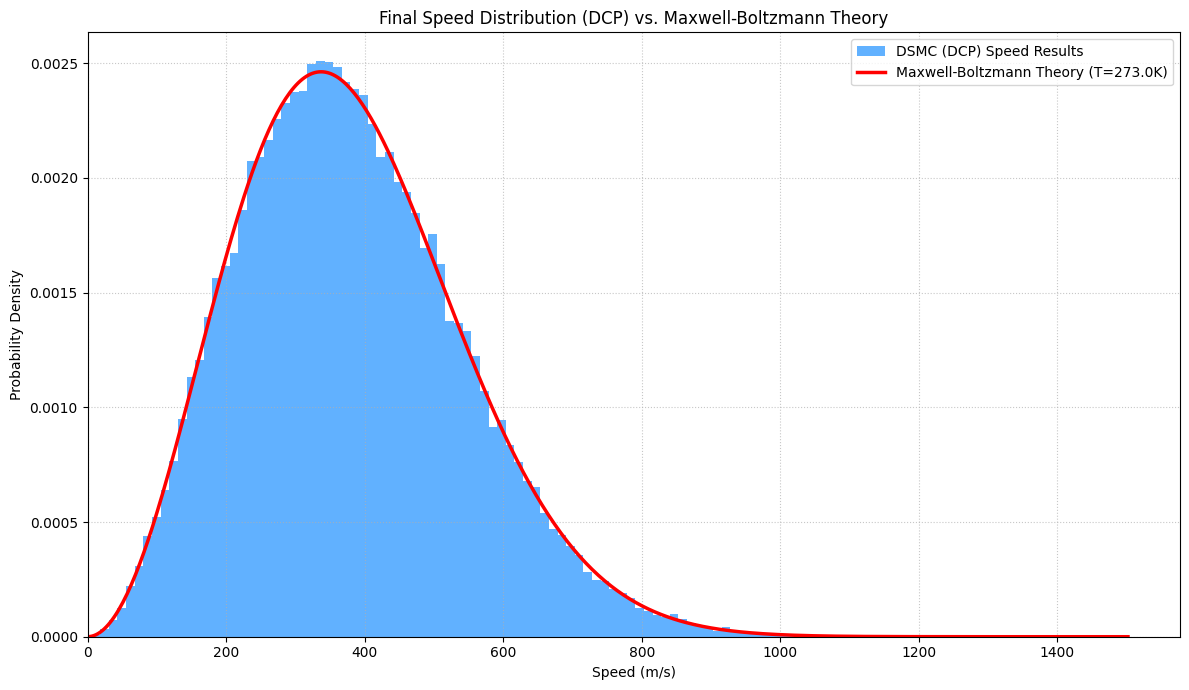

In [6]:
# -*- coding: utf-8 -*-
# --- DSMC RELAXATION - V2.1 - Interactive Choice & Updated Parameters ---
# This version prompts the user to choose a collision method and sets PPC=5.

import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.81

# --- SIMULATION PARAMETERS ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 400
PARTICLES_PER_CELL_INIT = 5  # <<< MODIFIED as per user request
TOTAL_PARTICLES_SIM = NUM_CELLS_X * PARTICLES_PER_CELL_INIT
N_DENSITY_REAL = RHO_INIT / MASS_AR
CELL_VOLUME_CONCEPTUAL = (LX**3) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 2.0e-12
TOTAL_TIME = 2.0e-8
SAMPLING_START_TIME = 5.0e-9
SAMPLING_INTERVAL = 2

# --- Initialization Function ---
def initialize_particles_non_equilibrium(rng_state):
    """Initializes particles with a uniform random velocity distribution."""
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    cell_width = LX / NUM_CELLS_X
    V_MAX_INITIAL = 800.0

    print("Initializing particles with a UNIFORM random velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX
    particles[:, 1:4] = V_MAX_INITIAL * (2.0 * rng_state.random((TOTAL_PARTICLES_SIM, 3)) - 1.0)

    current_ke = 0.5 * MASS_AR * np.sum(particles[:, 1:4]**2)
    target_ke = 1.5 * TOTAL_PARTICLES_SIM * KB * T_INIT
    scaling_factor = np.sqrt(target_ke / current_ke)
    particles[:, 1:4] *= scaling_factor

    print(f"Velocities scaled to match initial temperature T_INIT = {T_INIT}K.")
    return particles

# --- DSMC Core Functions ---

@njit(nopython=True)
def calculate_vhs_cross_section_numba(vr_mag):
    if vr_mag < 1e-9: return 1e-30
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = 1.04533
    d_sq = (D_REF_AR**2) * ((c_ref_sq / vr_mag**2)**exponent) * (1 / gamma_val)
    return np.pi * d_sq

# --- Method 1: Simplified Bernoulli Trials (SBT) ---
@njit(nopython=True)
def perform_collisions_sbt_numba(particles, indices_in_cell, cell_vol, dt, fnum, rng_state):
    max_prob_in_step = 0.0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0.0

    prob_const = fnum * dt / cell_vol
    for i in range(num_particles_in_cell):
        for j in range(i + 1, num_particles_in_cell):
            p1_idx = indices_in_cell[i]
            p2_idx = indices_in_cell[j]

            vrx, vry, vrz = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(vrx**2 + vry**2 + vrz**2)
            if vr_mag < 1e-9: continue

            sigma_t = calculate_vhs_cross_section_numba(vr_mag)
            collision_prob = prob_const * sigma_t * vr_mag
            if collision_prob > max_prob_in_step:
                max_prob_in_step = collision_prob

            if rng_state.random() < collision_prob:
                vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
                cos_chi = 2 * rng_state.random() - 1.0
                sin_chi = np.sqrt(1.0 - cos_chi**2)
                phi_chi = 2.0 * np.pi * rng_state.random()
                vr_prime = np.array([vr_mag*sin_chi*np.cos(phi_chi), vr_mag*sin_chi*np.sin(phi_chi), vr_mag*cos_chi])
                particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
                particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return max_prob_in_step

# --- Method 2: Deterministic Closest-Pair (DCP) ---
@njit
def generate_pairs_and_weights_distance(indices_in_cell, x_all, epsilon=1e-10):
    Nc = len(indices_in_cell)
    if Nc < 2: return np.empty((0, 2), dtype=np.int32), np.empty(0, dtype=np.float64)
    max_pairs = Nc * (Nc - 1) // 2
    pairs = np.empty((max_pairs, 2), dtype=np.int32)
    weights = np.empty(max_pairs, dtype=np.float64)
    pair_count = 0
    for i in range(Nc):
        p_a_id = indices_in_cell[i]
        for k in range(i + 1, Nc):
            p_b_id = indices_in_cell[k]
            distance = np.abs(x_all[p_a_id] - x_all[p_b_id])
            weights[pair_count] = 1.0 / (distance + epsilon)
            pairs[pair_count, 0] = p_a_id
            pairs[pair_count, 1] = p_b_id
            pair_count += 1
    return pairs[:pair_count], weights[:pair_count]

@njit
def classical_sample_pair_index_from_weights(weights, rng_state):
    if len(weights) == 0: return -1
    weights_sum = np.sum(weights)
    if weights_sum <= 1e-12: return -1
    probabilities = weights / weights_sum
    cumulative_probabilities = np.cumsum(probabilities)
    rand_val = rng_state.uniform(0.0, 1.0)
    return np.searchsorted(cumulative_probabilities, rand_val, side='right')

@njit(nopython=True)
def perform_collisions_dcp_numba(particles, indices_in_cell, cell_vol, dt, fnum, rng_state):
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0.0

    pairs, weights = generate_pairs_and_weights_distance(indices_in_cell, particles[:, 0])
    if len(pairs) == 0: return 0.0

    sum_of_sigma_g = 0.0
    for i in range(len(pairs)):
        p1_idx, p2_idx = pairs[i]
        vrx, vry, vrz = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(vrx**2 + vry**2 + vrz**2)
        if vr_mag > 1e-9:
            sum_of_sigma_g += calculate_vhs_cross_section_numba(vr_mag) * vr_mag

    expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
    num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))

    if num_collisions_to_perform <= 0: return 0.0

    for _ in range(num_collisions_to_perform):
        if np.sum(weights) < 1e-12: break

        selected_idx = classical_sample_pair_index_from_weights(weights, rng_state)
        if selected_idx == -1: continue

        p1_idx, p2_idx = pairs[selected_idx]

        vrx, vry, vrz = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(vrx**2 + vry**2 + vrz**2)
        if vr_mag < 1e-9: continue

        vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
        cos_chi = 2 * rng_state.random() - 1.0
        sin_chi = np.sqrt(1.0 - cos_chi**2)
        phi_chi = 2.0 * np.pi * rng_state.random()
        vr_prime = np.array([vr_mag*sin_chi*np.cos(phi_chi), vr_mag*sin_chi*np.sin(phi_chi), vr_mag*cos_chi])
        particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
        particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime

        weights[selected_idx] = 0.0

    return 0.0

# --- Plotting Function ---
def plot_speed_distribution(sampled_speeds, final_temp, method_name):
    print(f"Plotting final speed distribution for {method_name}...")
    plt.figure(figsize=(12, 7))
    plt.hist(sampled_speeds, bins=100, density=True, label=f'DSMC ({method_name}) Speed Results', alpha=0.7, color='dodgerblue')
    v_max_range = np.max(sampled_speeds) * 1.2
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * np.pi * KB * final_temp))**1.5 * 4 * np.pi * v_theory**2
                 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    plt.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Maxwell-Boltzmann Theory (T={final_temp:.1f}K)')
    plt.xlabel('Speed (m/s)'); plt.ylabel('Probability Density')
    plt.title(f'Final Speed Distribution ({method_name}) vs. Maxwell-Boltzmann Theory')
    plt.legend(); plt.grid(True, linestyle=':', alpha=0.7)
    plt.xlim(left=0); plt.ylim(bottom=0)
    plt.tight_layout(); plt.show()

# --- Main Simulation Driver ---
def run_dsmc_simulation(collision_method='SBT'):
    print(f"--- DSMC Relaxation to Maxwell-Boltzmann ---")
    print(f"--- Using Collision Method: {collision_method} ---")
    print(f"--- Particles per Cell: {PARTICLES_PER_CELL_INIT} ---")

    rng_state = np.random.default_rng()
    particles = initialize_particles_non_equilibrium(rng_state)

    sampled_speeds_accumulator = []
    max_overall_prob = 0.0

    start_time = time.time()
    print("\nStarting main simulation loop...")
    num_steps = int(TOTAL_TIME / DT)
    sampling_start_step = int(SAMPLING_START_TIME / DT)
    cell_width = LX / NUM_CELLS_X

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX

        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)
        sorted_particle_indices = np.argsort(cell_indices)
        cell_counts = np.bincount(cell_indices, minlength=NUM_CELLS_X)
        cell_start_indices = np.concatenate(([0], np.cumsum(cell_counts[:-1])))

        current_max_prob = 0.0
        for i in range(NUM_CELLS_X):
            start = cell_start_indices[i]
            end = start + cell_counts[i]
            indices_in_cell_i = sorted_particle_indices[start:end]

            if collision_method == 'SBT':
                max_p = perform_collisions_sbt_numba(particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state)
            elif collision_method == 'DCP':
                max_p = perform_collisions_dcp_numba(particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state)
            else:
                max_p = 0.0

            if max_p > current_max_prob:
                current_max_prob = max_p

        if current_max_prob > max_overall_prob:
            max_overall_prob = current_max_prob

        if step >= sampling_start_step and step % SAMPLING_INTERVAL == 0:
            speeds = np.sqrt(np.sum(particles[:, 1:4]**2, axis=1))
            sampled_speeds_accumulator.extend(speeds)

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps}...")

    end_time = time.time()
    print(f"Simulation finished in {end_time - start_time:.2f} seconds.\n")

    if max_overall_prob > 1.0:
        print(f"WARNING: Maximum collision probability reached {max_overall_prob:.3f}.")
        print("This is unphysical. The time step (DT) should be reduced.")
    else:
        print(f"Collision probability check passed (max prob = {max_overall_prob:.3f}).")

    final_temp = (2.0/3.0) * (0.5 * MASS_AR * np.sum(particles[:, 1:4]**2) / TOTAL_PARTICLES_SIM) / KB
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")

    if sampled_speeds_accumulator:
        plot_speed_distribution(np.array(sampled_speeds_accumulator), final_temp, collision_method)
    else:
        print("No speed data was sampled. Check SAMPLING_START_TIME and TOTAL_TIME.")

# ===================================================================
if __name__ == "__main__":
    # <<< MODIFIED: Interactive choice for collision method >>>
    while True:
        choice = input("Please choose the collision method:\n  [1] Simplified Bernoulli Trials (SBT)\n  [2] Deterministic Closest-Pair (DCP)\nEnter choice (1 or 2): ")
        if choice == '1':
            SELECTED_METHOD = 'SBT'
            break
        elif choice == '2':
            SELECTED_METHOD = 'DCP'
            break
        else:
            print("Invalid input. Please enter 1 or 2.")

    run_dsmc_simulation(collision_method=SELECTED_METHOD)

Please choose the collision method:
  [1] Simplified Bernoulli Trials (SBT)
  [2] Deterministic Closest-Pair (DCP)
Enter choice (1 or 2): 2
--- DSMC Relaxation to Maxwell-Boltzmann ---
--- Using Collision Method: DCP ---
--- Particles per Cell: 5 ---
Initializing particles with a UNIFORM random velocity distribution...
Velocities scaled to match initial temperature T_INIT = 273.0K.

Starting main simulation loop...
Step: 1000/10000...
Step: 2000/10000...
Step: 3000/10000...
Step: 4000/10000...
Step: 5000/10000...
Step: 6000/10000...
Step: 7000/10000...
Step: 8000/10000...
Step: 9000/10000...
Step: 10000/10000...
Simulation finished in 101.47 seconds.

Collision probability check passed (max prob = 0.000).
Final Equilibrium Temperature: 1022.49 K
Plotting final speed distribution for DCP...


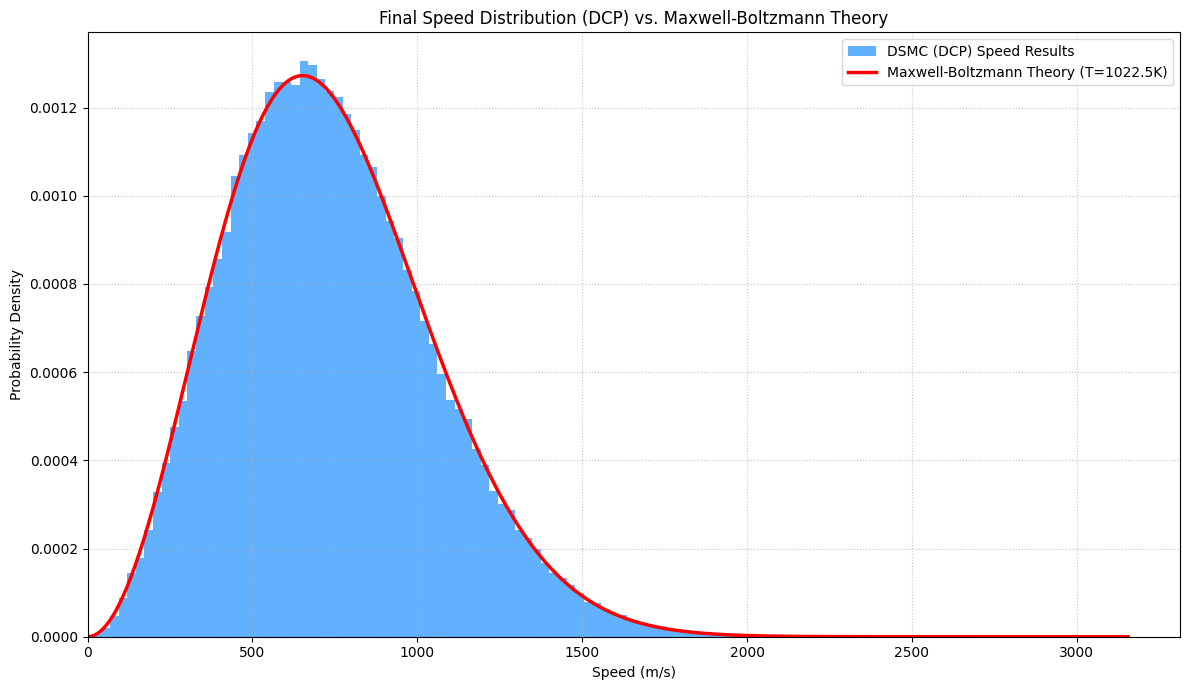

In [11]:
# -*- coding: utf-8 -*-
# --- DSMC RELAXATION - V2.2 - Final Complete & Corrected Code ---
# This version is a complete, runnable script with an interactive choice
# for the collision method and corrected decorators to prevent warnings.

import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit
import time

# --- Constants and Physical Parameters ---
MASS_AR = 39.948e-3 / 6.022e23
KB = 1.380649e-23
D_REF_AR = 4.17e-10
T_REF_AR = 273.0
OMEGA_VHS = 0.81

# --- SIMULATION PARAMETERS (can be modified here) ---
LX = 1.0e-6
RHO_INIT = 1.78
T_INIT = 273.0
NUM_CELLS_X = 400
PARTICLES_PER_CELL_INIT = 5  # As per user request
TOTAL_PARTICLES_SIM = NUM_CELLS_X * PARTICLES_PER_CELL_INIT
N_DENSITY_REAL = RHO_INIT / MASS_AR
CELL_VOLUME_CONCEPTUAL = (LX**3) / NUM_CELLS_X
FNUM = (N_DENSITY_REAL * CELL_VOLUME_CONCEPTUAL) / PARTICLES_PER_CELL_INIT
DT = 2.0e-12
TOTAL_TIME = 2.0e-8
SAMPLING_START_TIME = 5.0e-9
SAMPLING_INTERVAL = 2

# --- Initialization Function ---
def initialize_particles_non_equilibrium(rng_state):
    """Initializes particles with a uniform random velocity distribution."""
    particles = np.zeros((TOTAL_PARTICLES_SIM, 4))
    cell_width = LX / NUM_CELLS_X
    V_MAX_INITIAL = 800.0

    print("Initializing particles with a UNIFORM random velocity distribution...")
    particles[:, 0] = rng_state.random(TOTAL_PARTICLES_SIM) * LX
    particles[:, 1:4] = V_MAX_INITIAL * (2.0 * rng_state.random((TOTAL_PARTICLES_SIM, 3)) - 1.0)

    current_ke = 0.5 * MASS_AR * np.sum(particles[:, 1:4]**2)
    target_ke = 1.5 * TOTAL_PARTICLES_SIM * KB * T_INIT
    if current_ke > 1e-12: # Avoid division by zero if all velocities happen to be zero
        scaling_factor = np.sqrt(target_ke / current_ke)
        particles[:, 1:4] *= scaling_factor

    print(f"Velocities scaled to match initial temperature T_INIT = {T_INIT}K.")
    return particles

# --- DSMC Core Functions ---

@njit
def calculate_vhs_cross_section_numba(vr_mag):
    """Calculates the collision cross-section using the VHS model."""
    if vr_mag < 1e-9: return 1e-30
    exponent = OMEGA_VHS - 0.5
    c_ref_sq = 2 * KB * T_REF_AR / MASS_AR
    gamma_val = 1.04533
    d_sq = (D_REF_AR**2) * ((c_ref_sq / vr_mag**2)**exponent) * (1 / gamma_val)
    return np.pi * d_sq

# --- Method 1: Simplified Bernoulli Trials (SBT) ---
@njit
def perform_collisions_sbt_numba(particles, indices_in_cell, cell_vol, dt, fnum, rng_state):
    """Performs collisions in a cell using the Simplified Bernoulli Trials (SBT) scheme."""
    max_prob_in_step = 0.0
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2:
        return 0.0

    prob_const = fnum * dt / cell_vol
    for i in range(num_particles_in_cell):
        for j in range(i + 1, num_particles_in_cell):
            p1_idx = indices_in_cell[i]
            p2_idx = indices_in_cell[j]

            vrx, vry, vrz = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
            vr_mag = np.sqrt(vrx**2 + vry**2 + vrz**2)
            if vr_mag < 1e-9: continue

            sigma_t = calculate_vhs_cross_section_numba(vr_mag)
            collision_prob = prob_const * sigma_t * vr_mag
            if collision_prob > max_prob_in_step:
                max_prob_in_step = collision_prob

            if rng_state.random() < collision_prob:
                vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
                cos_chi = 2 * rng_state.random() - 1.0
                sin_chi = np.sqrt(1.0 - cos_chi**2)
                phi_chi = 2.0 * np.pi * rng_state.random()
                vr_prime = np.array([vr_mag*sin_chi*np.cos(phi_chi), vr_mag*sin_chi*np.sin(phi_chi), vr_mag*cos_chi])
                particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
                particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime
    return max_prob_in_step

# --- Method 2: Deterministic Closest-Pair (DCP) ---
@njit
def generate_pairs_and_weights_distance(indices_in_cell, x_all, epsilon=1e-10):
    Nc = len(indices_in_cell)
    if Nc < 2: return np.empty((0, 2), dtype=np.int32), np.empty(0, dtype=np.float64)
    max_pairs = Nc * (Nc - 1) // 2
    pairs = np.empty((max_pairs, 2), dtype=np.int32)
    weights = np.empty(max_pairs, dtype=np.float64)
    pair_count = 0
    for i in range(Nc):
        p_a_id = indices_in_cell[i]
        for k in range(i + 1, Nc):
            p_b_id = indices_in_cell[k]
            distance = np.abs(x_all[p_a_id] - x_all[p_b_id])
            weights[pair_count] = 1.0 / (distance + epsilon)
            pairs[pair_count, 0] = p_a_id
            pairs[pair_count, 1] = p_b_id
            pair_count += 1
    return pairs[:pair_count], weights[:pair_count]

@njit
def classical_sample_pair_index_from_weights(weights, rng_state):
    if len(weights) == 0: return -1
    weights_sum = np.sum(weights)
    if weights_sum <= 1e-12: return -1
    probabilities = weights / weights_sum
    cumulative_probabilities = np.cumsum(probabilities)
    rand_val = rng_state.uniform(0.0, 1.0)
    return np.searchsorted(cumulative_probabilities, rand_val, side='right')

@njit
def perform_collisions_dcp_numba(particles, indices_in_cell, cell_vol, dt, fnum, rng_state):
    num_particles_in_cell = len(indices_in_cell)
    if num_particles_in_cell < 2: return 0.0

    pairs, weights = generate_pairs_and_weights_distance(indices_in_cell, particles[:, 0])
    if len(pairs) == 0: return 0.0

    sum_of_sigma_g = 0.0
    for i in range(len(pairs)):
        p1_idx, p2_idx = pairs[i]
        vrx, vry, vrz = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(vrx**2 + vry**2 + vrz**2)
        if vr_mag > 1e-9:
            sum_of_sigma_g += calculate_vhs_cross_section_numba(vr_mag) * vr_mag

    expected_collisions = (sum_of_sigma_g * fnum * dt) / cell_vol
    num_collisions_to_perform = int(np.floor(expected_collisions + rng_state.random()))

    if num_collisions_to_perform <= 0: return 0.0

    for _ in range(num_collisions_to_perform):
        if np.sum(weights) < 1e-12: break

        selected_idx = np.argmax(weights) # Deterministic selection

        p1_idx, p2_idx = pairs[selected_idx]

        vrx, vry, vrz = particles[p1_idx, 1:4] - particles[p2_idx, 1:4]
        vr_mag = np.sqrt(vrx**2 + vry**2 + vrz**2)
        if vr_mag < 1e-9:
            weights[selected_idx] = 0.0 # Mark as unusable
            continue

        vcm = 0.5 * (particles[p1_idx, 1:4] + particles[p2_idx, 1:4])
        cos_chi = 2 * rng_state.random() - 1.0
        sin_chi = np.sqrt(1.0 - cos_chi**2)
        phi_chi = 2.0 * np.pi * rng_state.random()
        vr_prime = np.array([vr_mag*sin_chi*np.cos(phi_chi), vr_mag*sin_chi*np.sin(phi_chi), vr_mag*cos_chi])
        particles[p1_idx, 1:4] = vcm + 0.5 * vr_prime
        particles[p2_idx, 1:4] = vcm - 0.5 * vr_prime

        weights[selected_idx] = 0.0

    return 0.0

# --- Plotting Function ---
def plot_speed_distribution(sampled_speeds, final_temp, method_name):
    """Plots the final speed distribution histogram against the theoretical Maxwell-Boltzmann curve."""
    print(f"Plotting final speed distribution for {method_name}...")
    plt.figure(figsize=(12, 7))
    plt.hist(sampled_speeds, bins=100, density=True, label=f'DSMC ({method_name}) Speed Results', alpha=0.7, color='dodgerblue')
    v_max_range = np.max(sampled_speeds) * 1.2
    v_theory = np.linspace(0, v_max_range, 500)
    pv_theory = ((MASS_AR / (2 * np.pi * KB * final_temp))**1.5 * 4 * np.pi * v_theory**2
                 * np.exp(-MASS_AR * v_theory**2 / (2 * KB * final_temp)))
    plt.plot(v_theory, pv_theory, 'r-', linewidth=2.5, label=f'Maxwell-Boltzmann Theory (T={final_temp:.1f}K)')
    plt.xlabel('Speed (m/s)'); plt.ylabel('Probability Density')
    plt.title(f'Final Speed Distribution ({method_name}) vs. Maxwell-Boltzmann Theory')
    plt.legend(); plt.grid(True, linestyle=':', alpha=0.7)
    plt.xlim(left=0); plt.ylim(bottom=0)
    plt.tight_layout(); plt.show()

# --- Main Simulation Driver ---
def run_dsmc_simulation(collision_method='SBT'):
    """Main DSMC simulation loop with selectable collision method."""
    print(f"--- DSMC Relaxation to Maxwell-Boltzmann ---")
    print(f"--- Using Collision Method: {collision_method} ---")
    print(f"--- Particles per Cell: {PARTICLES_PER_CELL_INIT} ---")

    rng_state = np.random.default_rng()
    particles = initialize_particles_non_equilibrium(rng_state)

    sampled_speeds_accumulator = []
    max_overall_prob = 0.0

    start_time = time.time()
    print("\nStarting main simulation loop...")
    num_steps = int(TOTAL_TIME / DT)
    sampling_start_step = int(SAMPLING_START_TIME / DT)
    cell_width = LX / NUM_CELLS_X

    for step in range(1, num_steps + 1):
        particles[:, 0] += particles[:, 1] * DT
        particles[:, 0] %= LX

        cell_indices = (particles[:, 0] / cell_width).astype(np.int64)
        sorted_particle_indices = np.argsort(cell_indices)
        cell_counts = np.bincount(cell_indices, minlength=NUM_CELLS_X)
        cell_start_indices = np.concatenate((np.array([0]), np.cumsum(cell_counts[:-1])))

        current_max_prob = 0.0
        for i in range(NUM_CELLS_X):
            start = cell_start_indices[i]
            end = start + cell_counts[i]
            indices_in_cell_i = sorted_particle_indices[start:end]

            # <<< SELECTION OF COLLISION METHOD >>>
            if collision_method == 'SBT':
                max_p = perform_collisions_sbt_numba(particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state)
            elif collision_method == 'DCP':
                max_p = perform_collisions_dcp_numba(particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state)
            else: # Default to SBT if a wrong method is specified
                max_p = perform_collisions_sbt_numba(particles, indices_in_cell_i, CELL_VOLUME_CONCEPTUAL, DT, FNUM, rng_state)

            if max_p > current_max_prob:
                current_max_prob = max_p

        if current_max_prob > max_overall_prob:
            max_overall_prob = current_max_prob

        if step >= sampling_start_step and step % SAMPLING_INTERVAL == 0:
            speeds = np.sqrt(np.sum(particles[:, 1:4]**2, axis=1))
            sampled_speeds_accumulator.extend(speeds)

        if step % (num_steps // 10) == 0:
            print(f"Step: {step}/{num_steps}...")

    end_time = time.time()
    print(f"Simulation finished in {end_time - start_time:.2f} seconds.\n")

    if max_overall_prob > 1.0:
        print(f"WARNING: Maximum collision probability reached {max_overall_prob:.3f}.")
        print("This is unphysical. The time step (DT) should be reduced.")
    else:
        print(f"Collision probability check passed (max prob = {max_overall_prob:.3f}).")

    final_temp = (2.0/3.0) * (0.5 * MASS_AR * np.sum(particles[:, 1:4]**2) / TOTAL_PARTICLES_SIM) / KB
    print(f"Final Equilibrium Temperature: {final_temp:.2f} K")

    if sampled_speeds_accumulator:
        plot_speed_distribution(np.array(sampled_speeds_accumulator), final_temp, collision_method)
    else:
        print("No speed data was sampled. Check SAMPLING_START_TIME and TOTAL_TIME.")

# ===================================================================
if __name__ == "__main__":
    # --- Interactive choice for collision method ---
    while True:
        choice = input("Please choose the collision method:\n  [1] Simplified Bernoulli Trials (SBT)\n  [2] Deterministic Closest-Pair (DCP)\nEnter choice (1 or 2): ")
        if choice == '1':
            SELECTED_METHOD = 'SBT'
            break
        elif choice == '2':
            SELECTED_METHOD = 'DCP'
            break
        else:
            print("Invalid input. Please enter 1 or 2.")

    run_dsmc_simulation(collision_method=SELECTED_METHOD)